# Luhman 16B Doppler Imaging (spot_infer_ybs-style)

This notebook mirrors the workflow of paparazzi's `spot_infer_ybs.py` example, adapted to this project with synthetic high-resolution data.

Workflow:
1. Generate synthetic spectra with starry's Doppler forward model.
2. Instantiate a fresh `starry.DopplerMap` and solve with `map.solve(...)`.
3. Recover posterior diagnostics (`y_uncert`, `spectrum_guess`, `spectrum_uncert`).
4. Reproduce maps, spectra, and time-series style diagnostic plots.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 140

try:
    import starry
    HAS_DOPPLER = hasattr(starry, 'DopplerMap')
    IMPORT_ERROR = None
except Exception as exc:
    HAS_DOPPLER = False
    IMPORT_ERROR = exc

print(f'HAS_DOPPLER={HAS_DOPPLER}')
if IMPORT_ERROR is not None:
    print(f'Import warning: {IMPORT_ERROR}')

HAS_DOPPLER=True


In [25]:
def generate_synthetic_data(
    nt=16,
    R=30000,
    pixels_per_res=2.0,
    wl_min=3.45,
    wl_max=3.55,
    flux_err=8e-4,
    seed=2,
    ydeg=8,
    inc=70.0,
    veq=2.6e4,
    vsini_max=4.0e4,
    u=(0.5, 0.25),
):
    if not HAS_DOPPLER:
        raise RuntimeError('starry.DopplerMap is required for this tutorial.')

    rng = np.random.default_rng(seed)
    theta = np.linspace(-180.0, 180.0, nt, endpoint=False)

    # Log-uniform wavelength grid for nearly constant resolving power.
    dloglam = 1.0 / (R * pixels_per_res)
    nw = int(np.floor(np.log(wl_max / wl_min) / dloglam)) + 1
    wav = wl_min * np.exp(np.arange(nw) * dloglam)

    # Padded rest-frame wavelength grid.
    dlam_res = np.median(wav) / R
    pad = max(20.0 * dlam_res, 0.05 * (wl_max - wl_min))
    wav0 = np.linspace(wl_min - pad, wl_max + pad, 2 * nw)

    map_true = starry.DopplerMap(
        lazy=False,
        ydeg=int(ydeg),
        udeg=len(u),
        nc=1,
        veq=float(veq),
        inc=float(inc),
        vsini_max=float(vsini_max),
        nt=int(nt),
        wav=wav,
        wav0=wav0,
    )
    for n, un in enumerate(u):
        map_true[1 + n] = float(un)

    # Build a non-axisymmetric surface image to generate temporal variability.
    nlat, nlon = 64, 128
    lat = np.linspace(-90.0, 90.0, nlat)[:, None]
    lon = np.linspace(-180.0, 180.0, nlon, endpoint=False)[None, :]

    def angdiff(a, b):
        return (a - b + 180.0) % 360.0 - 180.0

    spot1 = np.exp(-0.5 * ((lat - 20.0) / 18.0) ** 2 - 0.5 * (angdiff(lon, 45.0) / 22.0) ** 2)
    spot2 = np.exp(-0.5 * ((lat + 25.0) / 14.0) ** 2 - 0.5 * (angdiff(lon, -80.0) / 18.0) ** 2)
    image = 1.0 - 0.20 * spot1 + 0.10 * spot2
    image = image / np.mean(image)

    spectrum_true = (
        1.0
        - 0.23 * np.exp(-0.5 * ((wav0 - 3.485) / 0.0018) ** 2)
        - 0.17 * np.exp(-0.5 * ((wav0 - 3.523) / 0.0023) ** 2)
    )

    map_true.load(map=image, spectrum=spectrum_true, smoothing=0.05)

    flux = np.asarray(map_true.flux(theta=theta, normalize=True))
    flux += flux_err * rng.standard_normal(size=flux.shape)
    flux_err_arr = np.full_like(flux, flux_err)

    return dict(
        kwargs=dict(
            ydeg=int(ydeg),
            udeg=len(u),
            nc=1,
            veq=float(veq),
            inc=float(inc),
            vsini_max=float(vsini_max),
            nt=int(nt),
            wav=wav,
            wav0=wav0,
        ),
        props=dict(u=np.array(u, dtype=float)),
        truths=dict(
            y=np.asarray(map_true.y).reshape(-1),
            spectrum=np.asarray(map_true.spectrum).reshape(-1),
        ),
        data=dict(
            theta=theta,
            flux=flux,
            flux_err=flux_err_arr,
        ),
        meta=dict(
            source=f'synthetic_starry_forward_R{int(R)}',
            R=float(R),
            flux_err=float(flux_err),
        ),
    )

In [26]:
data = generate_synthetic_data(
    nt=16,
    R=30000,
    pixels_per_res=2.0,
    wl_min=3.45,
    wl_max=3.55,
    flux_err=8e-4,
    seed=2,
)

theta = data['data']['theta']
flux = data['data']['flux']
flux_err = data['data']['flux_err']
wav = data['kwargs']['wav']
wav0 = data['kwargs']['wav0']
y_true = data['truths']['y']
spectrum_true = data['truths']['spectrum']

print(f"Data source: {data['meta']['source']}")
print('flux shape (nt, nw):', flux.shape)
print('Resolving power R:', int(data['meta']['R']))
print('Assumed per-pixel noise sigma:', data['meta']['flux_err'])

Data source: synthetic_starry_forward_R30000
flux shape (nt, nw): (16, 1715)
Resolving power R: 30000
Assumed per-pixel noise sigma: 0.0008


## Solve (spot_infer_ybs pattern)

This follows the same solve pattern as `spot_infer_ybs.py`:
- instantiate `starry.DopplerMap(lazy=False, **data['kwargs'])`
- set limb darkening from `data['props']['u']`
- solve jointly for map and spectrum with `map.solve(...)`
- compute posterior map and spectrum uncertainties from Cholesky factors.

In [28]:
if not HAS_DOPPLER:
    raise RuntimeError(
        'starry.DopplerMap is not available in this environment. '
        'Install a starry version with Doppler support to run this tutorial.'
    )

# Instantiate the map
map = starry.DopplerMap(lazy=False, **data['kwargs'])
for n in range(map.udeg):
    map[1 + n] = data['props']['u'][n]

# Solve for the Ylm coeffs and the spectrum (spot_infer_ybs pattern)
soln = map.solve(
    flux,
    theta=theta,
    normalized=True,
    flux_err=flux_err,
    quiet=True,
)

# Get the inferred map and spectrum
y_inferred = np.asarray(map.y).reshape(-1)
wav0 = np.asarray(map.wav0).reshape(-1)
wav = np.asarray(map.wav).reshape(-1)
spectrum_inferred = np.asarray(map.spectrum).reshape(-1)

# Compute the Ylm expansion of the posterior standard deviation field
if 'cho_ycov' in soln:
    P = np.asarray(map.sht_matrix(inverse=True))
    Q = np.asarray(map.sht_matrix())
    L = np.tril(np.asarray(soln['cho_ycov']))
    W = P @ L
    y_uncert = Q @ np.sqrt(np.diag(W @ W.T))
else:
    y_uncert = np.full_like(y_inferred, np.nan)

# Get the spectrum guess & uncertainty
if 'spectrum_guess' in soln and 'cho_scov' in soln and hasattr(map, '_S0i2eTr'):
    M = np.array(map._S0i2eTr.todense())  # converts from wav0_ grid to wav0 grid
    spectrum_guess = (np.asarray(soln['spectrum_guess']) @ M).reshape(-1)
    Ls = np.tril(np.asarray(soln['cho_scov']))
    spectrum_uncert = (np.sqrt(np.diag(Ls @ Ls.T)) @ M).reshape(-1)
else:
    spectrum_guess = np.full_like(spectrum_inferred, np.nan)
    spectrum_uncert = np.full_like(spectrum_inferred, np.nan)

model_flux = np.asarray(map.flux(theta=theta, normalize=True))
resid = flux - model_flux

print('solve keys:', sorted(soln.keys()))
print('RMS residual:', float(np.sqrt(np.mean(resid**2))))

solve keys: ['cho_scov', 'cho_ycov', 'spectrum_', 'spectrum_guess', 'y', 'y_lin']
RMS residual: 0.0007864028454986215


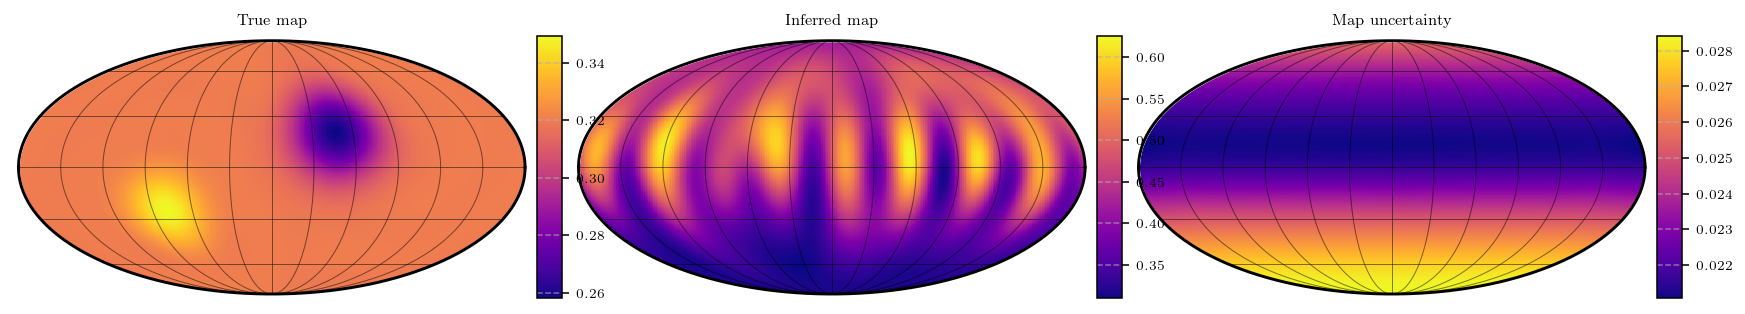

In [29]:
# Plot maps: true, inferred, and posterior uncertainty (spot_infer_ybs style diagnostics)
ydeg_plot = int(np.sqrt(y_true.size) - 1)
map_plot = starry.Map(ydeg=ydeg_plot, lazy=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

map_plot[:, :] = y_true
map_plot.show(ax=axes[0], projection='moll', colorbar=True)
axes[0].set_title('True map')

map_plot[:, :] = y_inferred
map_plot.show(ax=axes[1], projection='moll', colorbar=True)
axes[1].set_title('Inferred map')

if np.all(np.isfinite(y_uncert)):
    map_plot[:, :] = y_uncert
    map_plot.show(ax=axes[2], projection='moll', colorbar=True)
    axes[2].set_title('Map uncertainty')
else:
    axes[2].text(0.5, 0.5, 'No y covariance returned', ha='center', va='center')
    axes[2].set_axis_off()

plt.show()

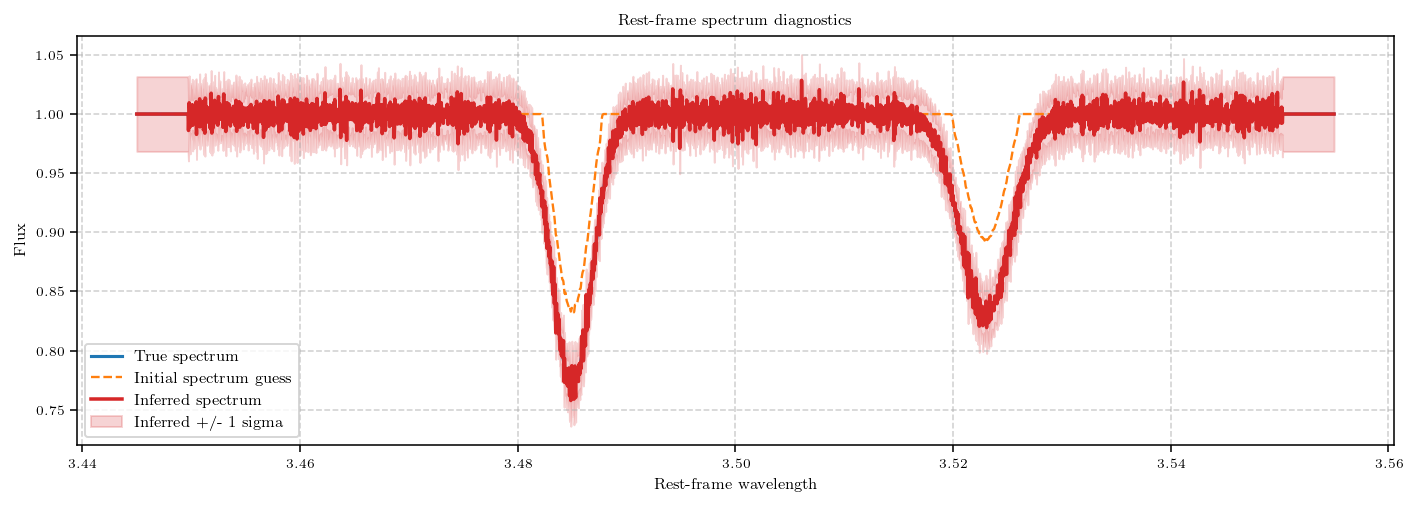

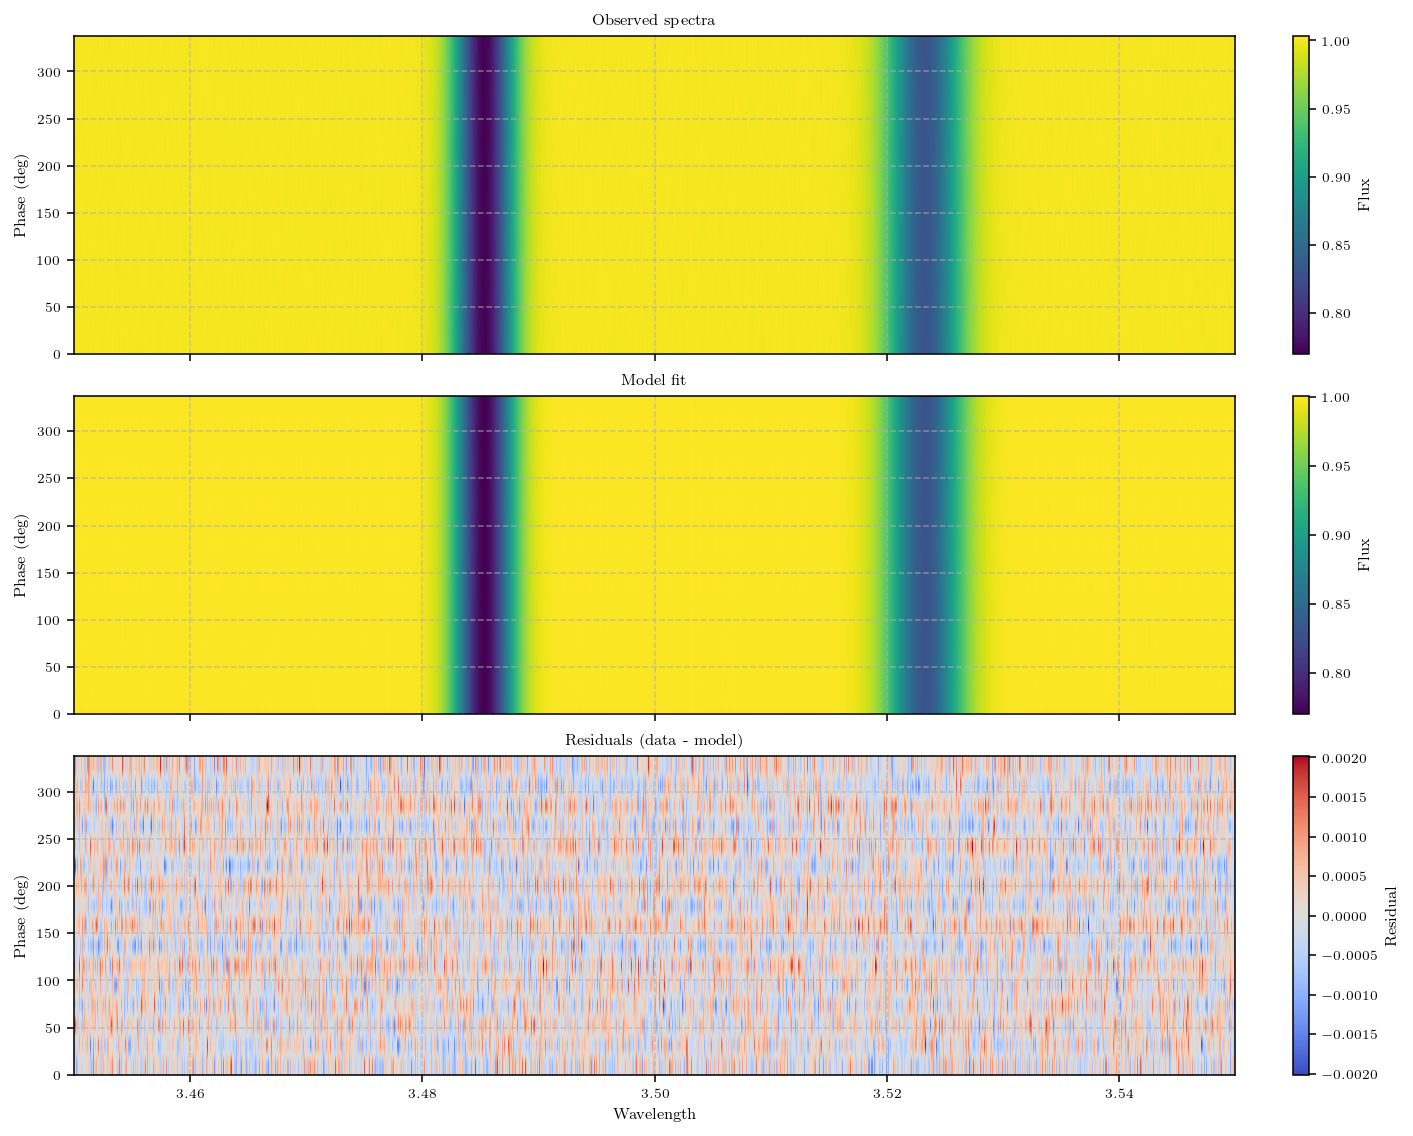

In [30]:
# Plot spectra: true, initial guess, inferred, and uncertainty
fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)

ax.plot(wav0, spectrum_true, lw=1.6, label='True spectrum', color='tab:blue')
if np.any(np.isfinite(spectrum_guess)):
    ax.plot(wav0, spectrum_guess, lw=1.2, ls='--', label='Initial spectrum guess', color='tab:orange')
ax.plot(wav0, spectrum_inferred, lw=1.8, label='Inferred spectrum', color='tab:red')

if np.any(np.isfinite(spectrum_uncert)):
    lo = spectrum_inferred - spectrum_uncert
    hi = spectrum_inferred + spectrum_uncert
    ax.fill_between(wav0, lo, hi, color='tab:red', alpha=0.2, label='Inferred +/- 1 sigma')

ax.set_title('Rest-frame spectrum diagnostics')
ax.set_xlabel('Rest-frame wavelength')
ax.set_ylabel('Flux')
ax.legend(loc='best', fontsize=8)
plt.show()

# Data/model/residual image diagnostics
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
extent = [wav.min(), wav.max(), theta.min(), theta.max()]

im0 = axes[0].imshow(flux, origin='lower', aspect='auto', extent=extent, cmap='viridis')
axes[0].set_title('Observed spectra')
axes[0].set_ylabel('Phase (deg)')
plt.colorbar(im0, ax=axes[0], label='Flux')

im1 = axes[1].imshow(model_flux, origin='lower', aspect='auto', extent=extent, cmap='viridis')
axes[1].set_title('Model fit')
axes[1].set_ylabel('Phase (deg)')
plt.colorbar(im1, ax=axes[1], label='Flux')

v = np.nanpercentile(np.abs(resid), 99)
im2 = axes[2].imshow(
    resid,
    origin='lower',
    aspect='auto',
    extent=extent,
    cmap='coolwarm',
    vmin=-v,
    vmax=v,
)
axes[2].set_title('Residuals (data - model)')
axes[2].set_ylabel('Phase (deg)')
axes[2].set_xlabel('Wavelength')
plt.colorbar(im2, ax=axes[2], label='Residual')

plt.show()

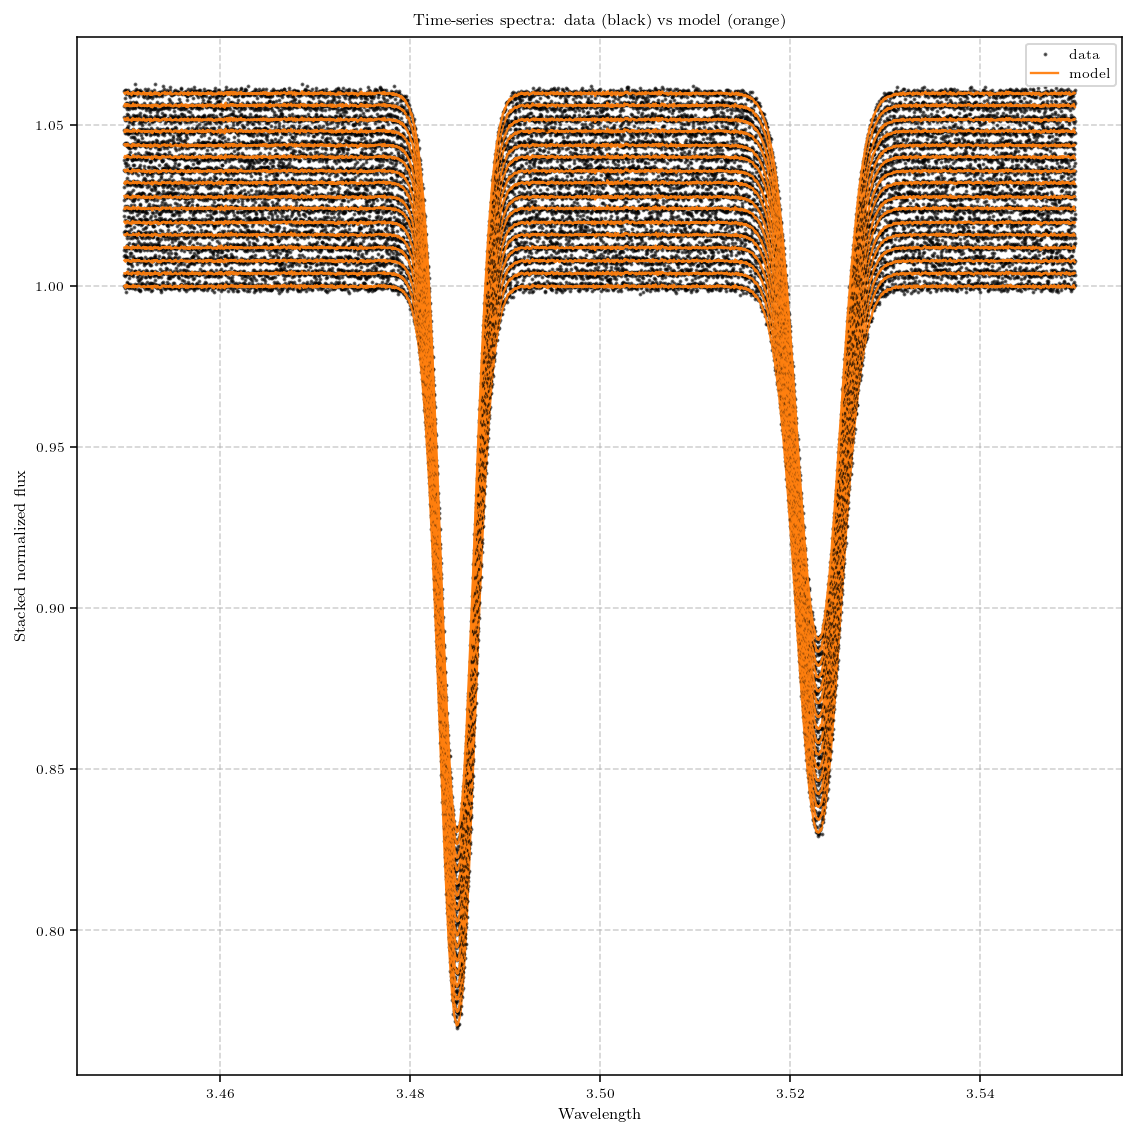

In [31]:
# Plot time series (Joy-Division style overlap)
order = np.argsort(theta)
theta_sorted = theta[order]
data_sorted = flux[order]
model_sorted = model_flux[order]

n_series = data_sorted.shape[0]
overlap = 5.0
offset = overlap * float(np.nanmedian(flux_err))

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
for i in range(n_series):
    baseline = i * offset
    label = 'data' if i == 0 else None
    ax.plot(wav, data_sorted[i] + baseline, '.', ms=2.0, color='k', alpha=0.55, label=label)
    label = 'model' if i == 0 else None
    ax.plot(wav, model_sorted[i] + baseline, '-', lw=1.2, color='tab:orange', alpha=0.95, label=label)

ax.set_title('Time-series spectra: data (black) vs model (orange)')
ax.set_xlabel('Wavelength')
ax.set_ylabel('Stacked normalized flux')
ax.legend(loc='upper right')
plt.show()

## Notes



- This tutorial intentionally uses synthetic high-resolution spectra at $R=30000$.

- The selected noise level is $\sigma\approx8\times10^{-4}$ per pixel in normalized flux, representative of high-SNR but realistic data.

- For noisier data, stronger priors are usually needed (spatial_cov ~ 2e-4, spectral_cov ~ 2e-2).

- The solve currently reports a point estimate for the spectrum and map; full uncertainty propagation can be added in a future probabilistic workflow.
